# Project 1: Credit Risk Scorecard
## Notebook 1: Data Understanding and EDA

### Project Context
Home Credit serves applicants who are invisible to traditional credit bureaus: migrant workers, first-time borrowers, and people in the informal economy. This scorecard predicts the probability of loan default using behavioural and financial signals, enabling loan officers to make faster, fairer, and more explainable lending decisions.

### Dataset
- Source: Home Credit Default Risk (Kaggle)
- File: application_train.csv
- Rows: 307,511 loan applications
- Target: TARGET (1 = defaulted, 0 = repaid)
- Note: Supplementary bureau and behavioural files excluded by design. See SOW Section 3 for rationale.

### Notebook Objectives
1. Understand the shape and quality of the data
2. Identify missing values and decide on handling strategy
3. Explore distributions of key features
4. Apply WOE encoding and rank features by Information Value
5. Produce EDA findings report for a non-technical credit officer

In [46]:
# import all the required libraries

import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [47]:
#Load Home Credit application training data

df = pd.read_csv(r'../Data/Raw/application_train.csv')
pd.set_option('display.max_columns', None)
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [48]:
from locale import normalize


print(df.shape)
print(df['TARGET'].value_counts(normalize = True) * 100)
missing = round(df.isnull().mean().sort_values(ascending=False) *100,2)
print('\n')
print(missing.head(20))

(307511, 122)
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


COMMONAREA_AVG              69.87
COMMONAREA_MODE             69.87
COMMONAREA_MEDI             69.87
NONLIVINGAPARTMENTS_MEDI    69.43
NONLIVINGAPARTMENTS_MODE    69.43
NONLIVINGAPARTMENTS_AVG     69.43
FONDKAPREMONT_MODE          68.39
LIVINGAPARTMENTS_AVG        68.35
LIVINGAPARTMENTS_MEDI       68.35
LIVINGAPARTMENTS_MODE       68.35
FLOORSMIN_MODE              67.85
FLOORSMIN_AVG               67.85
FLOORSMIN_MEDI              67.85
YEARS_BUILD_AVG             66.50
YEARS_BUILD_MODE            66.50
YEARS_BUILD_MEDI            66.50
OWN_CAR_AGE                 65.99
LANDAREA_MEDI               59.38
LANDAREA_AVG                59.38
LANDAREA_MODE               59.38
dtype: float64


## Initial Data Observations

**Dataset:** 307,511 loan applications, 122 features.

**Class Imbalance:** 91.9% of applicants repaid, 8.1% defaulted. 
This means a naive model that predicts "no default" for everyone 
achieves 92% accuracy but catches zero defaulters. Accuracy is 
therefore a useless metric. Evaluation must use Gini and KS statistic.

**Missing Values:** The top 20 columns by missingness are all 
building and apartment quality features (COMMONAREA, LIVINGAPARTMENTS, 
FLOORSMIN, YEARS_BUILD). These range from 66% to 70% missing. 
OWN_CAR_AGE is 66% missing, which makes sense: only applicants 
who own a car have a value here.

**Decision:** Columns with more than 40% missing values will be 
dropped before modelling. This removes most building features. 
Rationale: imputing 70% missing data introduces more noise than signal.


In [49]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,5.143927e-01,0.510853,0.11744,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,0.231894,0.066333,0.100775,0.107399,0.008809,0.028358,0.114231,0.087543,0.977065,0.759637,0.042553,0.074490,0.145193,0.222315,0.228058,0.064958,0.105645,0.105975,0.008076,0.027022,0.117850,0.087955,0.97

## Key Observations from describe()

**1. AMT_INCOME_TOTAL**
What I see: Max income is 117,000,000 (11.7 crore), far above the 
75th percentile of 202,500. This is a clear outlier.
What it means: Likely a data entry error. Someone earning 11.7 crore 
annually would not be a Home Credit customer. Extreme income values 
will be capped before modelling to prevent skewing the model.

**2. AMT_CREDIT and AMT_GOODS_PRICE**
What I see: Both columns share the same maximum value of 4,050,000.
What it means: Home Credit issues goods-backed loans. The loan amount 
is tied to a specific purchase, so high loan amounts are legitimate 
if the goods price justifies them. This is not a cash loan product.

**3. EXT_SOURCE_1, 2, 3**
What I see: Three anonymous external credit scores ranging from 0 to 1, 
with means around 0.5. EXT_SOURCE_1 has 56% missing values.
What it means: These are among the strongest predictors of default in 
this dataset. A low score signals poor repayment history from external 
sources. Missing values in EXT_SOURCE_1 need careful imputation as 
dropping them would lose 56% of the data.

**4. DAYS_BIRTH**
What I see: Stored as negative days from application date, ranging 
from -25,229 to -7,489. Will be converted to AGE_YEARS by dividing 
by -365.
What it means: Age is a strong credit risk signal. Younger applicants 
are statistically more likely to default, likely due to lower income 
stability and less financial experience. AGE_YEARS will be a key 
feature in the model.

**5. CNT_FAM_MEMBERS**
What I see: 75th percentile is 3 members but max is 20, which is 
a likely outlier.
What it means: Family size alone is not a risk signal. What matters 
is income relative to family size. A family of 5 with high combined 
income is lower risk than a family of 2 with very low income. This 
suggests creating a derived feature: income per family member.

**6. DAYS_EMPLOYED**
What I see: Max value is 365,243 days, which is approximately 1,000 
years. This is clearly an error code, not real data.
What it means: 365,243 is used as a placeholder for pensioners or 
unemployed applicants. This value must be replaced with NaN before 
modelling. Employment length is otherwise a strong stability signal: 
longer employment indicates more stable income and higher repayment 
capacity.

**7. OWN_CAR_AGE**
What I see: Ranges from 0 to 91 years with 66% missing values. 
Missing means the applicant does not own a car.
What it means: Car ownership signals financial stability. However 
a 91 year old car is implausible and likely a data entry error. 
The missing values are informative: not owning a car is itself 
a signal worth capturing as a binary FLAG_OWN_CAR feature already 
exists in the dataset.

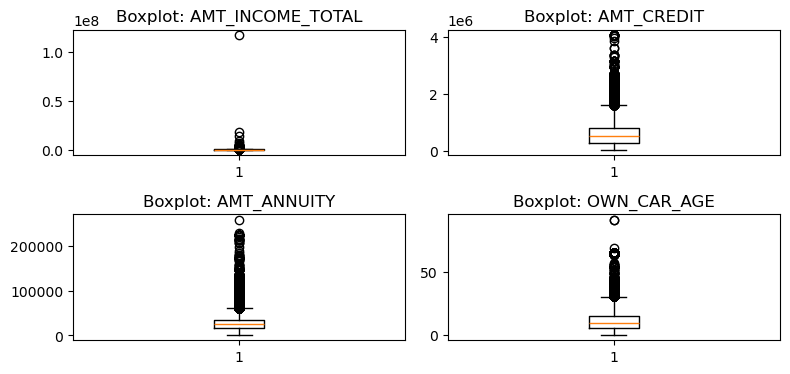

In [50]:
#plot boxplot

cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'OWN_CAR_AGE']

fig, axs = plt.subplots(2,2,figsize = (8, 4))

for col, ax in zip(cols, axs.flatten()):
    ax.boxplot(df[col].dropna())
    ax.set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()


### Outlier Analysis: Key Numeric Features

**AMT_INCOME_TOTAL:** One extreme outlier at 117,000,000 (11.7 crore). 
The entire distribution is compressed at the bottom because of this 
single value. Will cap at 99th percentile before modelling to prevent 
it from distorting the logistic regression coefficients.

**AMT_CREDIT:** Multiple outliers above 2,000,000 but these are 
legitimate high value goods-backed loans. Will keep but monitor 
during WOE binning. Extreme values will naturally fall into their 
own bin.

**AMT_ANNUITY:** One extreme outlier above 250,000 monthly repayment. 
Likely tied to the same high income outlier. Will cap alongside 
AMT_INCOME_TOTAL.

**OWN_CAR_AGE:** Outliers above 60 years are implausible. A 91 year 
old car does not exist as a reliable asset. Will cap at 60 years. 
Note 66% of this column is missing, meaning most applicants do not 
own a car. Missing values are informative, not random.

In [51]:
df['AGE_YEARS'] = df['DAYS_BIRTH'] / -365

# Replace error code in DAYS_EMPLOYED with NaN
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

### Investigating Null Values further

In [52]:
null_pct = df.isnull().mean().sort_values(ascending = True)
high_null = null_pct[null_pct > 0.6]
display(high_null)

OWN_CAR_AGE                 0.659908
YEARS_BUILD_MEDI            0.664978
YEARS_BUILD_AVG             0.664978
YEARS_BUILD_MODE            0.664978
FLOORSMIN_AVG               0.678486
FLOORSMIN_MEDI              0.678486
FLOORSMIN_MODE              0.678486
LIVINGAPARTMENTS_MODE       0.683550
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_AVG        0.683550
FONDKAPREMONT_MODE          0.683862
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
NONLIVINGAPARTMENTS_MEDI    0.694330
COMMONAREA_MODE             0.698723
COMMONAREA_AVG              0.698723
COMMONAREA_MEDI             0.698723
dtype: float64

### Missing Value Analysis

**OWN_CAR_AGE (MNAR):**
66% missing. Absence is informative: no car is itself a signal.
Old car = constrained income, new car = disposable income.
Will create a HAS_CAR binary flag before imputing so the model
learns from the missingness, not just the value.

**Apartment/Block Features (MAR):**
Describe the applicant's neighbourhood. Likely missing due to
inconsistent field data collection, not the client's profile.
Will impute with median grouped by region.


In [53]:
null_rate = round(df[df['OWN_CAR_AGE'].isnull()]['TARGET'].mean(),3) *100
present_rate = round(df[df['OWN_CAR_AGE'].notna()]['TARGET'].mean(),3) * 100

print(f'null rate: {null_rate}, present rate: {present_rate}, diference in defaulter rate: {round(null_rate - present_rate,3)}')

null rate: 8.5, present rate: 7.199999999999999, diference in defaulter rate: 1.3


8.5% vs 7.2% gives a difference of approx. 1.3 defaulters, in this data almost reperesenting 3991 applicantions from 307,000. Even though this number might seem insignificant, but in reality, that hundreds of crores in potential loss that your model would be blind to if dropped this column

In [54]:
print(df['TARGET'].value_counts())
print(df['TARGET'].unique())

TARGET
0    282686
1     24825
Name: count, dtype: int64
[1 0]


In [55]:
cor = df.corr(numeric_only=True)
target_cor = round(cor['TARGET'].sort_values(ascending=False) *100,2)
print(target_cor.head(10))
print(target_cor.tail(10))

TARGET                         100.00
DAYS_BIRTH                       7.82
DAYS_EMPLOYED                    7.50
REGION_RATING_CLIENT_W_CITY      6.09
REGION_RATING_CLIENT             5.89
DAYS_LAST_PHONE_CHANGE           5.52
DAYS_ID_PUBLISH                  5.15
REG_CITY_NOT_WORK_CITY           5.10
FLAG_EMP_PHONE                   4.60
REG_CITY_NOT_LIVE_CITY           4.44
Name: TARGET, dtype: float64
ELEVATORS_AVG                 -3.42
REGION_POPULATION_RELATIVE    -3.72
AMT_GOODS_PRICE               -3.96
FLOORSMAX_MODE                -4.32
FLOORSMAX_MEDI                -4.38
FLOORSMAX_AVG                 -4.40
AGE_YEARS                     -7.82
EXT_SOURCE_1                 -15.53
EXT_SOURCE_2                 -16.05
EXT_SOURCE_3                 -17.89
Name: TARGET, dtype: float64


In [57]:
target_cor['AGE_YEARS']

np.float64(-7.82)

## Correlation Analysis: Key Observations

**EXT_SOURCE dominates.** All three are 3 to 4x more correlated with TARGET
than anything else. These are your model's backbone. EXT_SOURCE_3 at -17.89
is the single strongest signal in the dataset.

**Age and employment are classic credit signals.** DAYS_BIRTH and DAYS_EMPLOYED
showing up makes complete sense. Older applicants and longer employment mean
more stability.

**Geography clusters together.** REGION_RATING, REG_CITY_NOT_WORK_CITY,
REG_CITY_NOT_LIVE_CITY all appear. Someone who lives, works, and is registered
in different cities is a mobility signal, and mobility can mean instability
or evasion.

**The building features at the bottom are weak.** Negative correlation but only
3-4%, likely just capturing neighbourhood income level indirectly. Probably
will not survive IV filtering.

**One flag:** raw correlation only captures linear relationships. WOE will
tell you more than this table for a logistic regression context.

In [59]:
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'] / -365

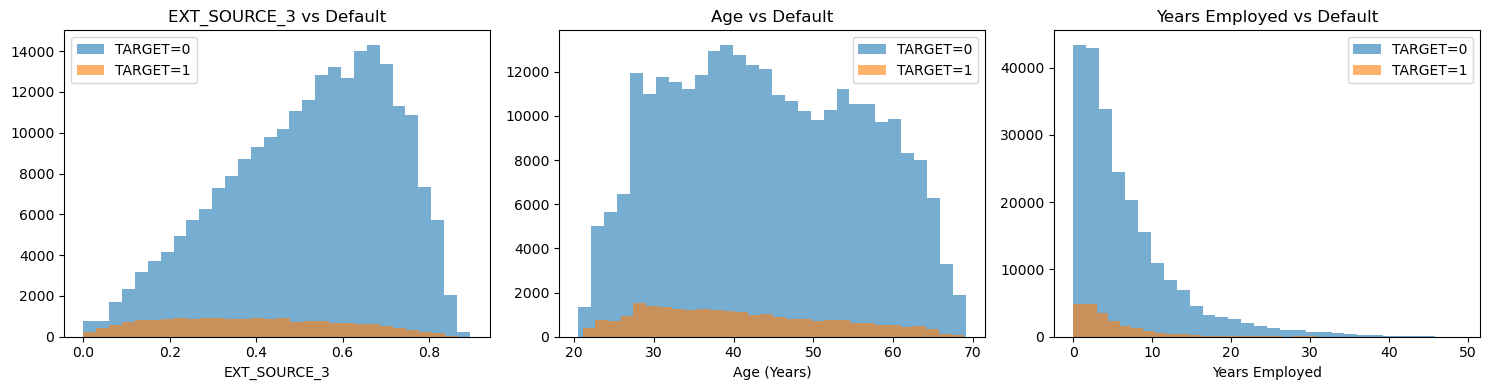

In [60]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# EXT_SOURCE_3 vs TARGET
for target, group in df.groupby('TARGET'):
    axs[0].hist(group['EXT_SOURCE_3'].dropna(), bins=30, alpha=0.6, label=f'TARGET={target}')
axs[0].set_title('EXT_SOURCE_3 vs Default')
axs[0].set_xlabel('EXT_SOURCE_3')
axs[0].legend()

# AGE_YEARS vs TARGET
for target, group in df.groupby('TARGET'):
    axs[1].hist(group['AGE_YEARS'].dropna(), bins=30, alpha=0.6, label=f'TARGET={target}')
axs[1].set_title('Age vs Default')
axs[1].set_xlabel('Age (Years)')
axs[1].legend()

# YEARS_EMPLOYED vs TARGET
for target, group in df.groupby('TARGET'):
    axs[2].hist(group['YEARS_EMPLOYED'].dropna(), bins=30, alpha=0.6, label=f'TARGET={target}')
axs[2].set_title('Years Employed vs Default')
axs[2].set_xlabel('Years Employed')
axs[2].legend()

plt.tight_layout()
plt.show()

C:\Users\urjad\AppData\Local\Temp\ipykernel_13948\145390298.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['AGE_YEARS'], bins=10))['TARGET'].mean().plot(kind='bar')


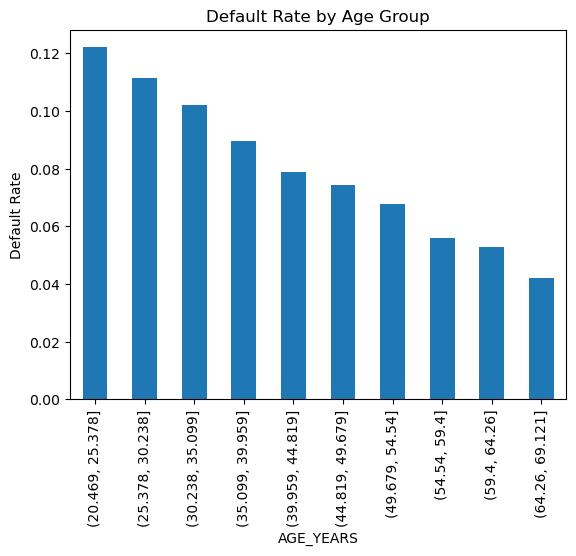

In [61]:
df.groupby(pd.cut(df['AGE_YEARS'], bins=10))['TARGET'].mean().plot(kind='bar')
plt.title('Default Rate by Age Group')
plt.ylabel('Default Rate')
plt.show()

1. Default rate declines monotonically with age. Applicants under 30
   have a 12% default rate, dropping to 4% by age 65. Younger applicants
   are consistently higher risk, not just more numerous.

2. Employment tenure under 5 years shows the highest default rates.
   Stability of income, not just presence of income, is the signal.

3. EXT_SOURCE_3 scores below 0.4 concentrate defaulters. Scores above
   0.5 show significantly lower default rates. This is your strongest
   single predictor.

In [69]:
#Income per family member
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']

#Outlier capping
for col in ['AMT_INCOME_TOTAL', 'AMT_ANNUITY']:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)

display(df['FLAG_OWN_CAR'].value_counts())
print((df['OWN_CAR_AGE'] >= 0).sum())
print(df['OWN_CAR_AGE'].isnull().sum())

FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64

104582
202929


a small data inconsistency, but nothing alarming.

### Weight of Evidence(WOE)